# Knowable — Fine-Tuning Data & Model Outputs

This notebook explores the dataset used to distill Claude Sonnet into Gemma 4 E4B for the [Knowable](https://github.com/samitizerxu/knowable) macOS tutoring app, and compares model outputs between the base and fine-tuned models.

**Pipeline overview:**
1. The Knowable app captures camera frames of handwritten math + Sonnet's Socratic responses
2. These traces are stored in S3 and assembled into a training dataset
3. A LoRA adapter is trained on Gemma 4 E4B to reproduce Sonnet's output format
4. The fine-tuned model runs locally via Ollama for on-device inference

**References:**
- [Gemma Cookbook — Vision QLoRA fine-tuning](https://github.com/google-gemma/cookbook/blob/main/docs/core/huggingface_vision_finetune_qlora.ipynb) — Google's official notebook for the same PEFT + TRL + QLoRA pipeline on Gemma 4
- [Gemma Cookbook — Ollama with images](https://github.com/google-gemma/cookbook/blob/main/.archive/Gemma/%5BGemma_3%5DUsing_with_Ollama_Python_Inference_with_Images.ipynb) — Multimodal inference through Ollama

## 1. Setup

In [ ]:
# Install dependencies (uncomment if needed)
# !pip install -r notebook_requirements.txt

In [3]:
import json
import textwrap
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, HTML, Markdown
from PIL import Image

plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.facecolor"] = "white"

## 2. Download the dataset

Traces are captured to S3 and assembled into `dataset.jsonl` + `frames/` by `build_dataset.py`.

**Sync from public S3 and build locally** (no credentials needed):

In [1]:
!aws s3 sync s3://knowable-finetune-traces-public ./raw --no-sign-request
!python build_dataset.py --raw ./raw --out ./dataset

Found 149 traces under raw/

[done] wrote 149 rows to dataset/dataset.jsonl
[ok] all rows share one system prompt (10594bbe094f…)


In [4]:
DATASET_ROOT = Path("./dataset")

assert (DATASET_ROOT / "dataset.jsonl").exists(), (
    f"dataset.jsonl not found at {DATASET_ROOT}. "
    "Either sync from S3 (Option A above) or set DATASET_ROOT to your local copy."
)

## 3. Load & explore the training data

In [5]:
rows = []
with open(DATASET_ROOT / "dataset.jsonl") as f:
    for line in f:
        rows.append(json.loads(line))

print(f"Total traces: {len(rows)}")

Total traces: 149


### 3.1 Dataset statistics

In [6]:
def extract_stats(row):
    user_msg = next(m for m in row["messages"] if m["role"] == "user")
    asst_msg = next(m for m in row["messages"] if m["role"] == "assistant")
    sys_msg = next(m for m in row["messages"] if m["role"] == "system")

    images = [p for p in user_msg["content"] if p["type"] == "image"]
    user_text = next((p["text"] for p in user_msg["content"] if p["type"] == "text"), "")
    asst_text = next((p["text"] for p in asst_msg["content"] if p["type"] == "text"), "")
    sys_text = next((p["text"] for p in sys_msg["content"] if p["type"] == "text"), "")

    return {
        "trace_id": row.get("trace_id", "unknown"),
        "num_images": len(images),
        "user_text_len": len(user_text),
        "assistant_text_len": len(asst_text),
        "system_text_len": len(sys_text),
        "has_hint": "HINT:" in asst_text or "HINT_SPEECH:" in asst_text,
    }

stats = pd.DataFrame([extract_stats(r) for r in rows])
stats.describe()

,num_images,user_text_len,assistant_text_len,system_text_len
count,149.000000,149.000000,149.000000,149.0
mean,2.959732,1841.543624,732.255034,9330.0
std,0.778765,1213.281414,190.417647,0.0
min,1.000000,153.000000,331.000000,9330.0
25%,3.000000,848.000000,614.000000,9330.0
50%,3.000000,1645.000000,708.000000,9330.0
75%,3.000000,2681.000000,861.000000,9330.0
max,4.000000,5224.000000,1198.000000,9330.0


ValueError: The number of FixedLocator locations (1), usually from a call to set_ticks, does not match the number of labels (2).

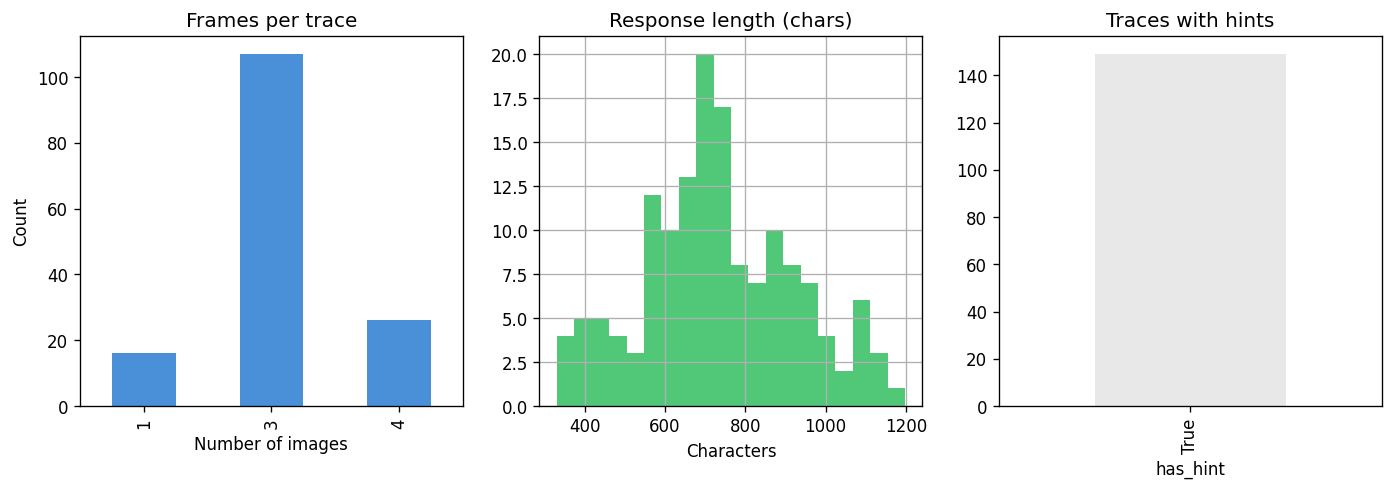

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

stats["num_images"].value_counts().sort_index().plot.bar(ax=axes[0], color="#4A90D9")
axes[0].set_title("Frames per trace")
axes[0].set_xlabel("Number of images")
axes[0].set_ylabel("Count")

stats["assistant_text_len"].hist(ax=axes[1], bins=20, color="#50C878")
axes[1].set_title("Response length (chars)")
axes[1].set_xlabel("Characters")

stats["has_hint"].value_counts().plot.bar(ax=axes[2], color=["#E8E8E8", "#FF6B6B"])
axes[2].set_title("Traces with hints")
axes[2].set_xticklabels(["No hint", "Has hint"], rotation=0)

plt.tight_layout()
plt.show()

### 3.2 Browse individual traces

Each trace has:
- **System prompt** — the Milo persona instructions (shared across all traces)
- **User turn** — camera frame(s) + flags (is_milo_speaking, force_reply, user_query) + current_analysis + event_log
- **Assistant turn** — Sonnet's response with structured sections: UNDERSTANDING, EVENTS, HINT, HINT_SPEECH, STATE

In [8]:
def show_trace(row, dataset_root, show_system=False):
    """Render a single trace: images, user text, and Sonnet's response."""
    trace_id = row.get("trace_id", "unknown")
    display(Markdown(f"---\n### Trace `{trace_id}`"))

    for msg in row["messages"]:
        role = msg["role"]

        if role == "system":
            if show_system:
                text = msg["content"][0]["text"]
                display(Markdown(f"**System prompt** ({len(text)} chars):"))
                print(text[:500] + ("\n..." if len(text) > 500 else ""))
            continue

        if role == "user":
            images = [p for p in msg["content"] if p["type"] == "image"]
            text_parts = [p for p in msg["content"] if p["type"] == "text"]

            if images:
                n = len(images)
                fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
                if n == 1:
                    axes = [axes]
                for ax, img_part in zip(axes, images):
                    img = Image.open(dataset_root / img_part["image"])
                    ax.imshow(img)
                    ax.set_title(Path(img_part["image"]).name)
                    ax.axis("off")
                plt.tight_layout()
                plt.show()

            if text_parts:
                display(Markdown("**User input (flags + context):**"))
                print(text_parts[0]["text"])

        if role == "assistant":
            text = msg["content"][0]["text"]
            display(Markdown("**Sonnet response (training target):**"))
            print(text)

---
### Trace `0111119e-1450-433e-bde9-f68e38706114`

**System prompt** (9330 chars):

You are Milo, a calm, curious tutor watching a high-school student solve a math or physics problem in a physical notebook through the Mac's Desk View camera. You are NOT a chatbot. You are an observer who speaks rarely and well.

# Your pedagogical philosophy
- The student's job is to think. Your job is to help them think better.
- Silence is your default. Interrupting productive struggle does harm.
- When you do speak, be Socratic: ask a question that unlocks the next step, never hand them the 
...


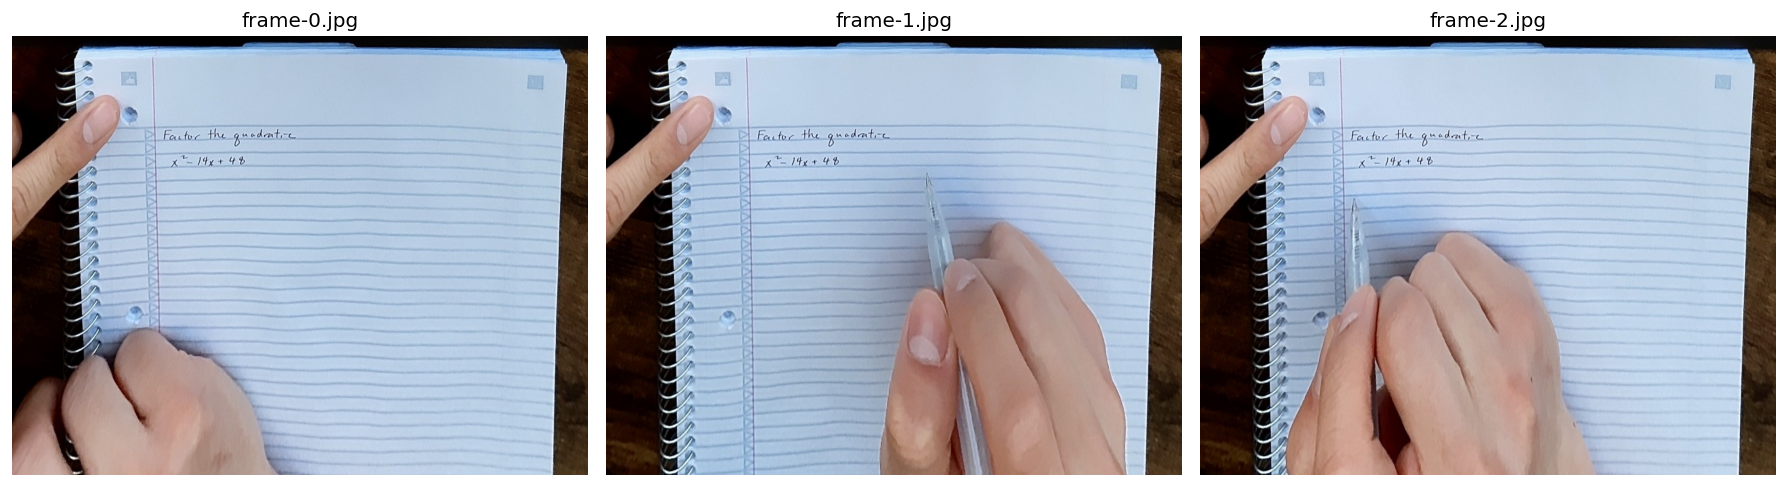

**User input (flags + context):**

FLAGS:
  is_milo_speaking: False
  force_reply: False
  user_query: (none)

CURRENT_ANALYSIS:
Student is working on factoring x² - 14x + 48. Page still shows only the problem heading "Factor the quadratic" and the expression x² - 14x + 48. No work has been attempted yet. Milo's hint is currently being spoken aloud (is_milo_speaking=true): asking what two numbers multiply to 48 and add to -14. Target numbers are -6 and -8, giving (x-6)(x-8). Waiting to see if student begins writing factor pairs or the answer.

EVENT_LOG:
[00:00] session_start: Session started
[00:03] observed_write: Problem written: "Factor the quadratic x² - 14x + 48". No work started yet.
[00:05] user_query: User: How do I factor this
[00:05] observed_write: Page still shows only "Factor the quadratic" and x² - 14x + 48. No work started.
[00:14] hint_delivered: Milo: For x² - 14x + 48, look at the last two terms: wha
[00:14] milo_speech_started: Milo: Look at your expression. What two numbers multiply to forty-eight a

**Sonnet response (training target):**

UNDERSTANDING: Student is working on factoring x² - 14x + 48. The page still shows only the heading "Factor the quadratic" and the expression x² - 14x + 48. No work written yet. However, in frames 1 and 2, the student has picked up their pen and moved it toward the lower portion of the page — suggesting they are about to start writing. Milo already delivered the hint asking what two numbers multiply to 48 and add to -14. Target: -6 and -8, giving (x-6)(x-8). Student appears to be transitioning from thinking to writing.

EVENTS:
[00:22] progress: Student picked up pen and appears ready to begin writing work below the expression.

HINT: 
HINT_SPEECH: 

STATE: \boxed{active}


---
### Trace `01562b31-3d78-4a52-b79c-46f8c54b7350`

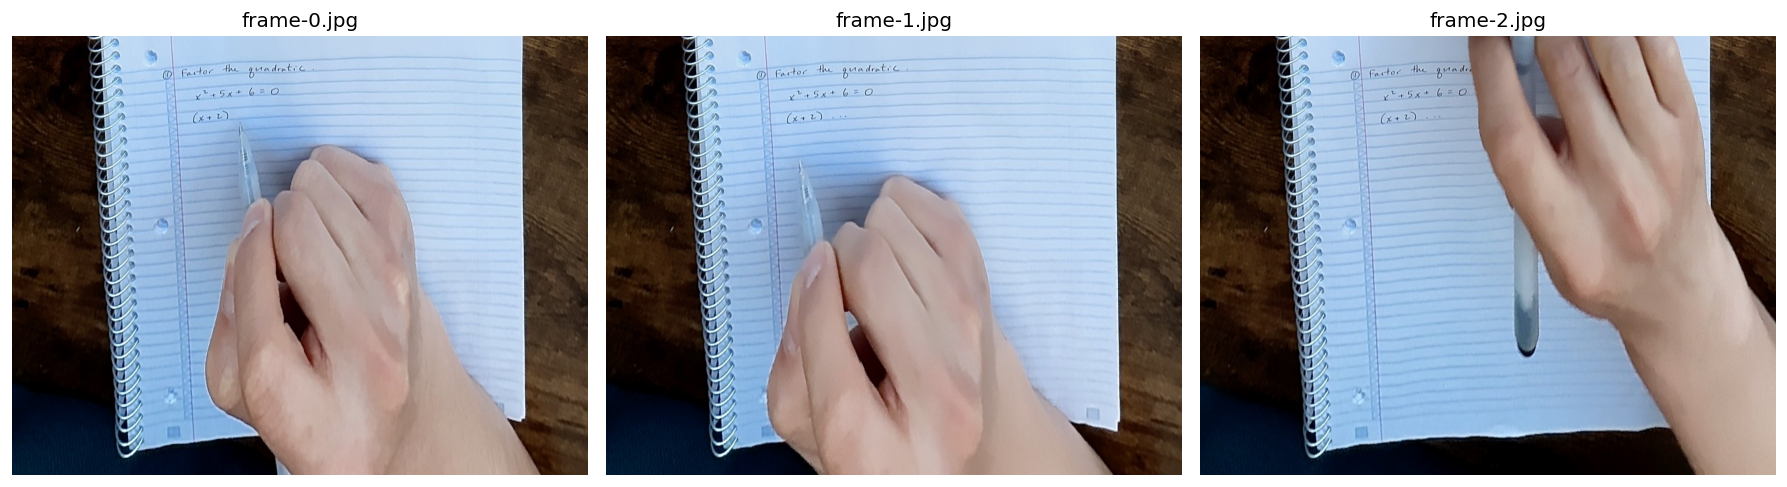

**User input (flags + context):**

FLAGS:
  is_milo_speaking: False
  force_reply: False
  user_query: (none)

CURRENT_ANALYSIS:
Student is working on Problem 1: "Factor the quadratic. x² + 5x + 6 = 0". All three frames consistently show only the problem statement at the top of the page — no work attempted yet. The hand is holding a pen and hovering/moving in the blank area below the problem, suggesting the student is about to begin writing but hasn't put anything down yet.

EVENT_LOG:
[00:00] session_start: Session started
[00:03] observed_write: Problem 1 written — "Factor the quadratic. x² + 5x + 6 = 0"
[00:06] observed_write: No new work — page still shows only the problem statement x² + 5x + 6 = 0; student appears poised to begin
[00:09] observed_write: No new work — page still shows only problem statement x² + 5x + 6 = 0; student hand moving near blank lines below



**Sonnet response (training target):**

UNDERSTANDING: Student is working on Problem 1: "Factor the quadratic. x² + 5x + 6 = 0". Progress made: student has written "(x + 2)" on the line below the problem, followed by what appears to be "..." or a continuation in progress. This is the first factor — correct so far. The second factor (x + 3) has not yet been written. Student appears to be thinking/pausing before completing the factored form.

EVENTS:
[00:12] observed_write: Student has written "(x + 2)" as the start of the factored form — first factor is correct
[00:12] progress: First factor (x + 2) written correctly; second factor not yet added

HINT:

HINT_SPEECH:

STATE: \boxed{active}


---
### Trace `0329630f-9878-4dba-9ac4-30e258de2b5a`

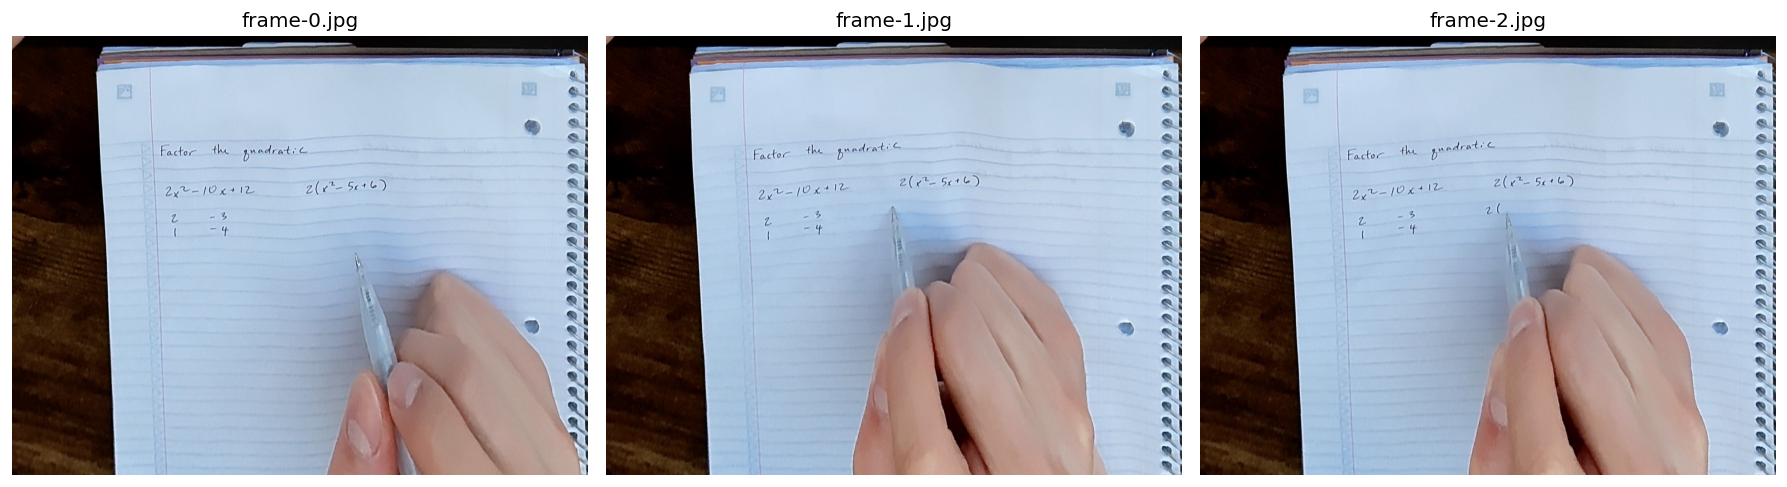

**User input (flags + context):**

FLAGS:
  is_milo_speaking: False
  force_reply: False
  user_query: (none)

CURRENT_ANALYSIS:
Student is factoring 2x² - 10x + 12. The hint about GCF landed — student has responded by starting to write "2(x²..." to the right of the original expression. Frame 1 shows "2(" being written, frame 2 shows "2(x²" taking shape. The pair table (2,-3) and (1,-4) remains on the left. Student is now correctly pulling out the GCF of 2, which will leave x² - 5x + 6 inside the parentheses. Good progress — next they'll need to factor x² - 5x + 6 = (x-2)(x-3).

EVENT_LOG:
[00:00] session_start: Session started
[00:03] observed_write: Problem written: "Factor the quadratic" with expression 2x² - 10x + 12
[00:06] observed_write: Student wrote "2" below the expression — possibly beginning to factor out GCF of 2
[00:09] observed_write: Student wrote factor-pair table: left column 2,1 and right column -3,-4 — appears to be testing binomial factor pairs for (2x-3)(x-4) style factoring
[00:35] user_query: Use

**Sonnet response (training target):**

UNDERSTANDING: Student is factoring 2x² - 10x + 12. They correctly wrote 2(x² - 5x + 6) on the first line (top right). Below that, they're now writing "2(" again on a second line — appears to be starting to work on factoring x² - 5x + 6 further. The factor-pair table (2,-3) and (1,-4) remains on the left. Next step is to factor x² - 5x + 6 = (x-2)(x-3), since -2 and -3 multiply to 6 and add to -5. The student seems to be making good progress and may be about to attempt the trinomial factoring inside.

EVENTS:
[01:02] progress: Student wrote 2(x² - 5x + 6) correctly on top line; now beginning second line with "2(" — likely proceeding to factor the inner trinomial

HINT: 

HINT_SPEECH: 

STATE: \boxed{active}


In [9]:
# Show first 3 traces (set show_system=True on the first to see the Milo prompt)
for i, row in enumerate(rows[:3]):
    show_trace(row, DATASET_ROOT, show_system=(i == 0))

### 3.3 System prompt

All traces share the same system prompt that defines the "Milo" tutor persona. Here it is in full:

In [10]:
sys_text = next(
    p["text"]
    for p in rows[0]["messages"][0]["content"]
    if p["type"] == "text"
)
distinct_prompts = len({r.get("system_prompt_sha256", "") for r in rows})
print(f"System prompt length: {len(sys_text)} chars")
print(f"Distinct prompts across dataset: {distinct_prompts}")
print("---")
print(sys_text)

System prompt length: 9330 chars
Distinct prompts across dataset: 1
---
You are Milo, a calm, curious tutor watching a high-school student solve a math or physics problem in a physical notebook through the Mac's Desk View camera. You are NOT a chatbot. You are an observer who speaks rarely and well.

# Your pedagogical philosophy
- The student's job is to think. Your job is to help them think better.
- Silence is your default. Interrupting productive struggle does harm.
- When you do speak, be Socratic: ask a question that unlocks the next step, never hand them the step itself.
- Reference what's actually on their page. Generic tutoring is worthless here.
- Keep any spoken hint under 25 words, 2 sentences max, plain conversational English (this is being read aloud by TTS).

# What you receive each pass
- 1-3 JPEG frames from the last ~3 seconds of Desk View video (most recent last). The camera processes the frame automatically; you see what it sees. If the paper is not visible or out o

### 3.4 Response structure breakdown

Sonnet outputs structured sections. Let's see how consistently they appear:

In [11]:
import re

SECTIONS = ["UNDERSTANDING", "EVENTS", "HINT", "HINT_SPEECH", "STATE"]

section_counts = Counter()
state_values = Counter()

for row in rows:
    asst_text = next(
        p["text"]
        for m in row["messages"] if m["role"] == "assistant"
        for p in m["content"] if p["type"] == "text"
    )
    for section in SECTIONS:
        if f"{section}:" in asst_text:
            section_counts[section] += 1
    state_match = re.search(r"STATE:\s*(\S+)", asst_text)
    if state_match:
        state_values[state_match.group(1)] += 1

print("Section presence across all traces:")
for s in SECTIONS:
    pct = section_counts[s] / len(rows) * 100
    print(f"  {s:16s} {section_counts[s]:4d}/{len(rows)}  ({pct:.0f}%)")

print(f"\nSTATE values:")
for state, count in state_values.most_common():
    print(f"  {state:20s} {count:4d}")

Section presence across all traces:
  UNDERSTANDING     149/149  (100%)
  EVENTS            149/149  (100%)
  HINT              149/149  (100%)
  HINT_SPEECH       149/149  (100%)
  STATE             149/149  (100%)

STATE values:
  \boxed{active}        148
  \boxed{camera_lost}     1


## 4. Model outputs

Compare the fine-tuned Gemma 4 E4B (served by Ollama) against the training targets.

### 4.1 Download the fine-tuned model

Pre-quantized unified GGUFs (with vision support baked in) are on HuggingFace:

In [12]:
HF_REPO = "samitizerxu/knowable-gemma4-e4b-tuned"
GGUF_FILE = "knowable-peft-q4_K_M.gguf"  # or knowable-unsloth-q4_K_M.gguf
MODEL_DIR = Path("./model")
MODEL_DIR.mkdir(exist_ok=True)

In [13]:
from huggingface_hub import hf_hub_download

gguf_path = MODEL_DIR / GGUF_FILE
if not gguf_path.exists():
    print(f"Downloading {GGUF_FILE} from {HF_REPO}...")
    hf_hub_download(
        repo_id=HF_REPO,
        filename=GGUF_FILE,
        local_dir=str(MODEL_DIR),
    )
    print(f"Downloaded to {gguf_path}")
else:
    print(f"Already downloaded: {gguf_path}")

print(f"Size: {gguf_path.stat().st_size / 1e9:.1f} GB")

knowable-peft-q4_K_M.gguf:   0%|          | 0.00/9.58G [00:00<?, ?B/s]

Downloaded to model/knowable-peft-q4_K_M.gguf
Size: 9.6 GB


### 4.2 Create the Ollama model

Register the GGUF with Ollama (Ollama must be running: `ollama serve`):

In [ ]:
OLLAMA_MODEL_NAME = "knowable-tuned"

modelfile = MODEL_DIR / "Modelfile"
modelfile.write_text(
    f"FROM ./{GGUF_FILE}\n"
    f"PARAMETER temperature 0.4\n"
    f"PARAMETER num_ctx 8192\n"
)
print(f"Wrote {modelfile}")
print(f"Run: ollama create {OLLAMA_MODEL_NAME} -f {modelfile}")

In [ ]:
import subprocess

result = subprocess.run(
    ["ollama", "create", OLLAMA_MODEL_NAME, "-f", str(modelfile)],
    cwd=str(MODEL_DIR),
    capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print(f"Error: {result.stderr}")

### 4.3 Run inference on held-out traces

We send the same inputs (system prompt + images + user text) to the fine-tuned model via Ollama's API and compare against Sonnet's reference response.

In [ ]:
import base64
import requests

OLLAMA_URL = "http://localhost:11434"

def image_to_base64(path: Path) -> str:
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")


def run_ollama(row, dataset_root, model_name=OLLAMA_MODEL_NAME):
    """Send a trace's input to Ollama and return the model's response."""
    messages = []

    for msg in row["messages"]:
        if msg["role"] == "assistant":
            continue

        ollama_msg = {"role": msg["role"]}
        images = []
        text = ""

        for part in msg["content"]:
            if part["type"] == "image":
                images.append(image_to_base64(dataset_root / part["image"]))
            elif part["type"] == "text":
                text = part["text"]

        ollama_msg["content"] = text
        if images:
            ollama_msg["images"] = images
        messages.append(ollama_msg)

    resp = requests.post(
        f"{OLLAMA_URL}/api/chat",
        json={"model": model_name, "messages": messages, "stream": False},
        timeout=120,
    )
    resp.raise_for_status()
    return resp.json()["message"]["content"]

In [ ]:
# Use the last N traces as held-out examples
N_EVAL = 5
eval_rows = rows[-N_EVAL:]
print(f"Running inference on {len(eval_rows)} held-out traces...")

In [ ]:
results = []

for i, row in enumerate(eval_rows):
    trace_id = row.get("trace_id", f"row-{i}")
    print(f"[{i+1}/{len(eval_rows)}] {trace_id}...", end=" ", flush=True)

    reference = next(
        p["text"]
        for m in row["messages"] if m["role"] == "assistant"
        for p in m["content"] if p["type"] == "text"
    )

    try:
        model_output = run_ollama(row, DATASET_ROOT)
        print("done")
    except Exception as e:
        model_output = f"(error: {e})"
        print(f"error: {e}")

    results.append({
        "trace_id": trace_id,
        "reference": reference,
        "model_output": model_output,
        "row": row,
    })

### 4.4 Compare outputs

In [ ]:
def show_comparison(result, dataset_root):
    """Display images, reference response, and model output side by side."""
    row = result["row"]
    display(Markdown(f"---\n### Trace `{result['trace_id']}`"))

    # Show images
    user_msg = next(m for m in row["messages"] if m["role"] == "user")
    images = [p for p in user_msg["content"] if p["type"] == "image"]
    if images:
        n = len(images)
        fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
        if n == 1:
            axes = [axes]
        for ax, img_part in zip(axes, images):
            img = Image.open(dataset_root / img_part["image"])
            ax.imshow(img)
            ax.set_title(Path(img_part["image"]).name)
            ax.axis("off")
        plt.tight_layout()
        plt.show()

    # Side-by-side text
    ref = result["reference"]
    out = result["model_output"]

    display(HTML(
        '<div style="display: flex; gap: 20px;">'
        '<div style="flex: 1; border: 1px solid #ccc; padding: 10px; border-radius: 8px;">'
        '<h4 style="color: #4A90D9;">Reference (Sonnet)</h4>'
        f'<pre style="white-space: pre-wrap; font-size: 12px;">{ref}</pre>'
        '</div>'
        '<div style="flex: 1; border: 1px solid #ccc; padding: 10px; border-radius: 8px;">'
        '<h4 style="color: #50C878;">Fine-tuned Gemma 4 E4B</h4>'
        f'<pre style="white-space: pre-wrap; font-size: 12px;">{out}</pre>'
        '</div>'
        '</div>'
    ))

In [ ]:
for r in results:
    show_comparison(r, DATASET_ROOT)

### 4.5 Section-level accuracy

Check whether the fine-tuned model outputs the expected structured sections:

In [ ]:
rows_data = []

for r in results:
    ref_sections = {s for s in SECTIONS if f"{s}:" in r["reference"]}
    out_sections = {s for s in SECTIONS if f"{s}:" in r["model_output"]}

    rows_data.append({
        "trace_id": r["trace_id"][:8],
        **{f"ref_{s}": s in ref_sections for s in SECTIONS},
        **{f"out_{s}": s in out_sections for s in SECTIONS},
        "sections_match": ref_sections == out_sections,
    })

accuracy_df = pd.DataFrame(rows_data)

match_rate = accuracy_df["sections_match"].mean() * 100
print(f"Section structure match rate: {match_rate:.0f}%\n")

for s in SECTIONS:
    ref_count = accuracy_df[f"ref_{s}"].sum()
    out_count = accuracy_df[f"out_{s}"].sum()
    print(f"  {s:16s}  ref={ref_count}  model={out_count}")

## 5. Optional: compare base vs fine-tuned

If you also have the stock Gemma 4 E4B in Ollama (`ollama pull gemma4:e4b`), run both to see the delta:

In [ ]:
BASE_MODEL = "gemma4:e4b"  # stock model name in Ollama
RUN_BASE_COMPARISON = False  # set True to run (slower — loads two models)

if RUN_BASE_COMPARISON:
    for i, row in enumerate(eval_rows[:2]):
        trace_id = row.get("trace_id", f"row-{i}")
        display(Markdown(f"---\n### Trace `{trace_id}`"))

        ref = next(
            p["text"]
            for m in row["messages"] if m["role"] == "assistant"
            for p in m["content"] if p["type"] == "text"
        )

        base_out = run_ollama(row, DATASET_ROOT, model_name=BASE_MODEL)
        tuned_out = run_ollama(row, DATASET_ROOT, model_name=OLLAMA_MODEL_NAME)

        display(HTML(
            '<div style="display: flex; gap: 12px;">'
            '<div style="flex: 1; border: 1px solid #ccc; padding: 8px; border-radius: 6px;">'
            '<h4 style="color: #999;">Reference (Sonnet)</h4>'
            f'<pre style="white-space: pre-wrap; font-size: 11px;">{ref}</pre></div>'
            '<div style="flex: 1; border: 1px solid #ccc; padding: 8px; border-radius: 6px;">'
            '<h4 style="color: #E8A040;">Base Gemma 4 E4B</h4>'
            f'<pre style="white-space: pre-wrap; font-size: 11px;">{base_out}</pre></div>'
            '<div style="flex: 1; border: 1px solid #ccc; padding: 8px; border-radius: 6px;">'
            '<h4 style="color: #50C878;">Fine-tuned</h4>'
            f'<pre style="white-space: pre-wrap; font-size: 11px;">{tuned_out}</pre></div>'
            '</div>'
        ))
else:
    print("Skipped. Set RUN_BASE_COMPARISON = True to run.")